# 04C - Comparacion presentable de modelos top V2

Este notebook compara solamente los tres modelos seleccionados para defensa y presentacion:

- XGBoost
- HistGradientBoosting
- Logistic Regression

Objetivo: dejar tablas, graficas, matrices de confusion, configuraciones destacadas ya encontradas, diagnostico de overfitting y una prediccion en vivo usando el dataset V2 multibacteria binario.

Importante: este notebook no vuelve a hacer busqueda de hiperparametros. Usa configuraciones fijas tomadas de los resultados previos para que sea rapido y facil de presentar.

## 1. Librerias y rutas

Se usan rutas relativas para que el notebook funcione desde la carpeta del proyecto. Los resultados se guardan separados en `05_RESULTADOS/top3_presentacion` y `GRAFICAS/top3_presentacion`.

In [15]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_DISPONIBLE = True
except Exception as exc:
    XGBOOST_DISPONIBLE = False
    XGBOOST_ERROR = exc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RUTA_NOTEBOOK = Path.cwd()
if RUTA_NOTEBOOK.name == "04_MODELADO":
    RUTA_V2 = RUTA_NOTEBOOK.parent
else:
    RUTA_V2 = Path("modelo") / "V2"

RUTA_DATOS = RUTA_V2 / "DATOS_PROCESADOS" / "09_dataset_v2_multibacteria_balanceado_organismo_clase.csv"
RUTA_RESULTADOS = RUTA_V2 / "05_RESULTADOS" / "top3_presentacion"
RUTA_GRAFICAS = RUTA_V2 / "GRAFICAS" / "top3_presentacion"

RUTA_RESULTADOS.mkdir(parents=True, exist_ok=True)
RUTA_GRAFICAS.mkdir(parents=True, exist_ok=True)

print("Dataset:", RUTA_DATOS.resolve())
print("Resultados:", RUTA_RESULTADOS.resolve())
print("Graficas:", RUTA_GRAFICAS.resolve())

Dataset: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\DATOS_PROCESADOS\09_dataset_v2_multibacteria_balanceado_organismo_clase.csv
Resultados: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\05_RESULTADOS\top3_presentacion
Graficas: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\GRAFICAS\top3_presentacion


## 2. Configuracion metodologica

- Variable objetivo: `susceptibility`.
- Clases: `Susceptible` y `Resistant`.
- Clase positiva para metricas probabilisticas: `Resistant`.
- Metrica principal de seleccion: `f1_macro`.
- Se usan hiperparametros destacados de entrenamientos previos para no repetir busquedas costosas.
- Se calcula MSE como metrica auxiliar porque el profesor la pidio, aunque para clasificacion no es la metrica principal.

In [16]:
TARGET = "susceptibility"
CLASES_VALIDAS = ["Susceptible", "Resistant"]
MAPEO_TARGET = {"Susceptible": 0, "Resistant": 1}
MAPEO_INVERSO = {0: "Susceptible", 1: "Resistant"}

TEST_SIZE = 0.20
RANDOM_STATE = 42
CV_SPLITS = 3
N_JOBS = 4

# Para calcular importancia sin volver lento el notebook.
CALCULAR_IMPORTANCIA = True
N_FILAS_IMPORTANCIA = 2500
N_REPEATS_IMPORTANCIA = 5

UMBRAL_OVERFITTING_BAJO = 0.03
UMBRAL_OVERFITTING_MODERADO = 0.08

print("Configuracion lista")

Configuracion lista


## 3. Carga del dataset final V2

Se usa el dataset balanceado por organismo y clase porque es el mas defendible para comparar varias bacterias sin que una clase u organismo domine demasiado el entrenamiento.

In [17]:
if not RUTA_DATOS.exists():
    raise FileNotFoundError(f"No existe el dataset esperado: {RUTA_DATOS}")

df = pd.read_csv(RUTA_DATOS)

if TARGET not in df.columns:
    raise ValueError(f"No existe la columna objetivo {TARGET}")

df = df[df[TARGET].isin(CLASES_VALIDAS)].copy()
df[TARGET] = df[TARGET].astype(str)

print("Shape:", df.shape)
display(df.head())
display(df[TARGET].value_counts().rename_axis(TARGET).reset_index(name="filas"))

if "organism" in df.columns:
    display(pd.crosstab(df["organism"], df[TARGET]))

Shape: (242923, 69)


,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,ordering_mode,culture_description,organism,antibiotic,susceptibility,age,...,exp_prev_tetracycline,exp_prev_urinary_antiseptic,comorb_chronic_pulmonary_any,comorb_congestive_heart_failure,comorb_diabetes_any,comorb_organ_transplant_status,comorb_pancreatic_disorder,comorb_renal_failure,comorb_sinusitis,comorb_solid_tumor_non_metastatic
0,JC1466131,131262759980,591206288,2019-02-08 19:47:00+00:00,Null,URINE,ESCHERICHIA COLI,Amikacin,Susceptible,35-44 years,...,0,0,0,1,0,0,0,0,0,0
1,JC6319015,131340453889,819574108,2022-08-31 09:05:00+00:00,Inpatient,URINE,PROTEUS MIRABILIS,Ceftriaxone,Susceptible,75-84 years,...,0,0,0,1,1,0,0,0,0,0
2,JC2001249,131237232404,533224864,2017-07-14 22:14:00+00:00,Outpatient,URINE,KLEBSIELLA PNEUMONIAE,Cefoxitin,Susceptible,75-84 years,...,0,0,1,1,0,0,0,0,1,0
3,JC2909850,131280584151,643491973,2020-01-06 06:59:00+00:00,Inpatient,URINE,ESCHERICHIA COLI,Cefazolin,Susceptible,25-34 years,...,0,0,0,0,0,0,0,0,0,0
4,JC2155246,131239597994,539581654,2017-11-03 04:29:00+00:00,Inpatient,BLOOD,PSEUDOMONAS AERUGINOSA,Amikacin,Susceptible,35-44 years,...,0,0,0,1,0,0,0,0,0,0


,susceptibility,filas
0,Susceptible,150000
1,Resistant,92923


susceptibility,Resistant,Susceptible
organism,,
ENTEROCOCCUS SPECIES,12242,25000
ESCHERICHIA COLI,25000,25000
KLEBSIELLA PNEUMONIAE,20624,25000
PROTEUS MIRABILIS,11731,25000
PSEUDOMONAS AERUGINOSA,5460,25000
STAPHYLOCOCCUS AUREUS,17866,25000


## 4. Seleccion de variables predictoras

Se excluyen identificadores, fechas y columnas que podrian introducir fuga de informacion. El modelo debe aprender de variables clinicas/microbiologicas, no memorizar IDs.

In [18]:
patrones_exclusion = [
    "id",
    "coded",
    "date",
    "time",
    "culture_time",
    "collection",
    "result_time",
]

columnas_excluir = {TARGET}
for col in df.columns:
    col_lower = col.lower()
    if any(patron in col_lower for patron in patrones_exclusion):
        columnas_excluir.add(col)

# Estas columnas solo se excluyen si existen. Evitan fuga directa o campos administrativos.
columnas_excluir.update([
    "susceptibility_binary",
    "label",
    "target",
    "Antibiotic",
    "Rule",
    "implied_susceptibility",
])

features = [col for col in df.columns if col not in columnas_excluir]

X = df[features].copy()
y = df[TARGET].map(MAPEO_TARGET).astype(int)

numeric_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_cols = [col for col in X.columns if col not in numeric_cols]

resumen_variables = pd.DataFrame({
    "tipo": ["numericas", "categoricas", "total"],
    "cantidad": [len(numeric_cols), len(categorical_cols), len(features)],
})

display(resumen_variables)
display(pd.DataFrame({"variable": features}).head(80))

pd.DataFrame({"variable": features}).to_csv(RUTA_RESULTADOS / "00_variables_usadas_top3.csv", index=False)

,tipo,cantidad
0,numericas,50
1,categoricas,6
2,total,56


,variable
0,ordering_mode
1,culture_description
2,organism
3,antibiotic
4,age
5,gender
6,hosp_ward_IP
7,hosp_ward_OP
8,hosp_ward_ER
9,hosp_ward_ICU


## 5. Train/test split estratificado

Si existe `organism`, el split se estratifica por combinacion `organism + susceptibility`. Esto ayuda a que cada bacteria conserve una distribucion parecida en entrenamiento y prueba.

In [19]:
if "organism" in df.columns:
    stratify_col = df["organism"].astype(str) + "__" + df[TARGET].astype(str)
    conteo_strata = stratify_col.value_counts()
    if (conteo_strata < 2).any():
        print("Algunas combinaciones organismo/clase tienen menos de 2 filas. Se estratifica solo por target.")
        stratify_values = y
    else:
        stratify_values = stratify_col
else:
    stratify_values = y

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_values,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
display(pd.Series(y_train).map(MAPEO_INVERSO).value_counts().rename_axis("train").reset_index(name="filas"))
display(pd.Series(y_test).map(MAPEO_INVERSO).value_counts().rename_axis("test").reset_index(name="filas"))

Train: (194338, 56) Test: (48585, 56)


,train,filas
0,Susceptible,120000
1,Resistant,74338


,test,filas
0,Susceptible,30000
1,Resistant,18585


## 6. Preprocesamiento y configuraciones destacadas

Se usan dos tipos de preprocesamiento:

- Logistic Regression y XGBoost: One-Hot Encoding para variables categoricas.
- HistGradientBoosting: Ordinal Encoding para evitar matrices densas muy grandes.

Cada modelo queda configurado con la mejor configuracion destacada previamente. Esto evita repetir `GridSearchCV` y convierte el notebook en una pieza de presentacion/evaluacion.

In [20]:
def convertir_categoricas_a_texto(X):
    """Normaliza categoricas mixtas para evitar errores entre int y str en los encoders."""
    if isinstance(X, pd.DataFrame):
        return X.astype("string").fillna("SIN_REGISTRO").astype(str)
    return pd.DataFrame(X).astype("string").fillna("SIN_REGISTRO").astype(str)


cat_to_text = FunctionTransformer(convertir_categoricas_a_texto, validate=False)

preprocess_onehot = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", Pipeline([
            ("to_text", cat_to_text),
            ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
        ]), categorical_cols),
    ],
    remainder="drop",
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline([
            ("to_text", cat_to_text),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), categorical_cols),
    ],
    remainder="drop",
)

configuraciones_destacadas = {
    "hist_gradient_boosting": {
        "fuente": "resultado_hist_gradient_boosting_local_rapido_v2_binario_balanceado_organismo_clase.csv",
        "parametros": {
            "l2_regularization": 2.0,
            "learning_rate": 0.12,
            "max_iter": 440,
            "max_leaf_nodes": 95,
            "min_samples_leaf": 40,
        },
    },
    "logistic_regression": {
        "fuente": "resultado_logistic_regression_local_rapido_v2_binario_balanceado_organismo_clase.csv",
        "parametros": {
            "C": 0.3219596952967591,
            "fit_intercept": True,
            "penalty": "l2",
            "solver": "lbfgs",
            "tol": 0.0001,
        },
    },
}

modelos = {
    "hist_gradient_boosting": Pipeline([
        ("preprocess", preprocess_tree),
        ("model", HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            **configuraciones_destacadas["hist_gradient_boosting"]["parametros"],
        )),
    ]),
    "logistic_regression": Pipeline([
        ("preprocess", preprocess_onehot),
        ("model", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=2000,
            class_weight="balanced",
            n_jobs=N_JOBS,
            **configuraciones_destacadas["logistic_regression"]["parametros"],
        )),
    ]),
}

if XGBOOST_DISPONIBLE:
    configuraciones_destacadas["xgboost"] = {
        "fuente": "resultado_xgboost_local_rapido_v2_binario_balanceado_organismo_clase.csv",
        "parametros": {
            "colsample_bytree": 0.95,
            "learning_rate": 0.12,
            "max_depth": 8,
            "min_child_weight": 5,
            "n_estimators": 600,
            "reg_alpha": 0.1,
            "reg_lambda": 5.0,
            "subsample": 0.95,
        },
    }
    modelos["xgboost"] = Pipeline([
        ("preprocess", preprocess_onehot),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            **configuraciones_destacadas["xgboost"]["parametros"],
        )),
    ])
else:
    print("XGBoost no esta disponible:", XGBOOST_ERROR)

df_configuraciones = pd.DataFrame([
    {
        "modelo": nombre,
        "fuente": info["fuente"],
        "parametros_fijos": json.dumps(info["parametros"], ensure_ascii=False),
    }
    for nombre, info in configuraciones_destacadas.items()
])
df_configuraciones.to_csv(RUTA_RESULTADOS / "02_configuraciones_destacadas_top3.csv", index=False)
display(df_configuraciones)

,modelo,fuente,parametros_fijos
0,hist_gradient_boosting,resultado_hist_gradient_boosting_local_rapido_...,"{""l2_regularization"": 2.0, ""learning_rate"": 0...."
1,logistic_regression,resultado_logistic_regression_local_rapido_v2_...,"{""C"": 0.3219596952967591, ""fit_intercept"": tru..."
2,xgboost,resultado_xgboost_local_rapido_v2_binario_bala...,"{""colsample_bytree"": 0.95, ""learning_rate"": 0...."


## 7. Ajuste de modelos con hiperparametros fijos

Aqui solo se ajustan los tres modelos con las configuraciones destacadas. No se hace busqueda de hiperparametros. El objetivo es generar resultados presentables y reproducibles rapidamente.

In [21]:
mejores_modelos = {}
resumen_ajuste = []

for nombre, modelo in modelos.items():
    print("\nAjustando modelo con configuracion fija:", nombre)
    modelo.fit(X_train, y_train)
    mejores_modelos[nombre] = modelo
    resumen_ajuste.append({
        "modelo": nombre,
        "configuracion": json.dumps(configuraciones_destacadas[nombre]["parametros"], ensure_ascii=False),
        "fuente_configuracion": configuraciones_destacadas[nombre]["fuente"],
    })

df_resumen_ajuste = pd.DataFrame(resumen_ajuste)
df_resumen_ajuste.to_csv(RUTA_RESULTADOS / "01_modelos_ajustados_configuracion_fija.csv", index=False)
display(df_resumen_ajuste)


Ajustando modelo con configuracion fija: hist_gradient_boosting

Ajustando modelo con configuracion fija: logistic_regression

Ajustando modelo con configuracion fija: xgboost


,modelo,configuracion,fuente_configuracion
0,hist_gradient_boosting,"{""l2_regularization"": 2.0, ""learning_rate"": 0....",resultado_hist_gradient_boosting_local_rapido_...
1,logistic_regression,"{""C"": 0.3219596952967591, ""fit_intercept"": tru...",resultado_logistic_regression_local_rapido_v2_...
2,xgboost,"{""colsample_bytree"": 0.95, ""learning_rate"": 0....",resultado_xgboost_local_rapido_v2_binario_bala...


## 8. Evaluacion completa en test

Aqui se calculan las metricas importantes para mostrar:

- Accuracy
- Balanced accuracy
- Precision macro
- Recall macro
- F1 macro
- ROC AUC
- Average precision
- MSE
- Gap train/test para diagnostico de overfitting

In [22]:
def clasificar_overfitting(gap):
    if gap <= UMBRAL_OVERFITTING_BAJO:
        return "bajo"
    if gap <= UMBRAL_OVERFITTING_MODERADO:
        return "moderado"
    return "alto"


def obtener_prob_resistant(modelo, X_eval):
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(X_eval)[:, 1]
    if hasattr(modelo, "decision_function"):
        scores = modelo.decision_function(X_eval)
        return 1 / (1 + np.exp(-scores))
    return None


metricas = []
predicciones = {}

for nombre, modelo in mejores_modelos.items():
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    y_prob_test = obtener_prob_resistant(modelo, X_test)

    f1_train = f1_score(y_train, y_pred_train, average="macro")
    f1_test = f1_score(y_test, y_pred_test, average="macro")
    gap = f1_train - f1_test

    fila = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred_test),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),
        "precision_macro": precision_score(y_test, y_pred_test, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred_test, average="macro", zero_division=0),
        "f1_macro": f1_test,
        "mse": mean_squared_error(y_test, y_pred_test),
        "f1_macro_train": f1_train,
        "f1_macro_test": f1_test,
        "gap_overfitting_f1_macro": gap,
        "nivel_overfitting": clasificar_overfitting(gap),
    }

    if y_prob_test is not None:
        fila["roc_auc"] = roc_auc_score(y_test, y_prob_test)
        fila["average_precision"] = average_precision_score(y_test, y_prob_test)
    else:
        fila["roc_auc"] = np.nan
        fila["average_precision"] = np.nan

    metricas.append(fila)
    predicciones[nombre] = {
        "y_pred_test": y_pred_test,
        "y_prob_test": y_prob_test,
    }

    reporte = classification_report(
        y_test,
        y_pred_test,
        target_names=[MAPEO_INVERSO[0], MAPEO_INVERSO[1]],
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(reporte).T.to_csv(RUTA_RESULTADOS / f"reporte_clasificacion_{nombre}.csv")

df_metricas = pd.DataFrame(metricas).sort_values("f1_macro", ascending=False)
df_metricas.to_csv(RUTA_RESULTADOS / "03_metricas_test_top3.csv", index=False)
display(df_metricas)

,modelo,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,mse,f1_macro_train,f1_macro_test,gap_overfitting_f1_macro,nivel_overfitting,roc_auc,average_precision
0,hist_gradient_boosting,0.857219,0.843119,0.852026,0.843119,0.847029,0.142781,0.891030,0.847029,0.044001,moderado,0.932128,0.897263
2,xgboost,0.854153,0.838844,0.849433,0.838844,0.843382,0.145847,0.883252,0.843382,0.039871,moderado,0.929739,0.894868
1,logistic_regression,0.763775,0.767411,0.754936,0.767411,0.757178,0.236225,0.755581,0.757178,-0.001597,bajo,0.838217,0.729493


## 9. Matriz de confusion de cada modelo

La matriz de confusion muestra cuantos casos fueron clasificados correctamente o confundidos entre `Susceptible` y `Resistant`.

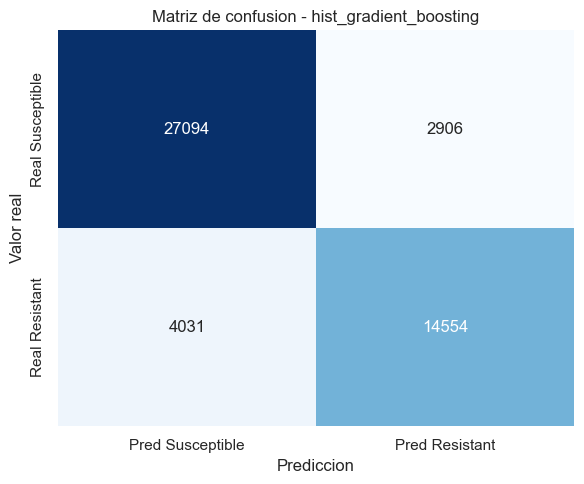

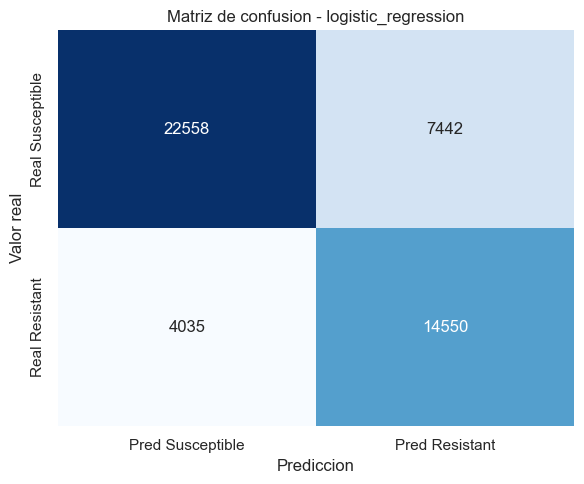

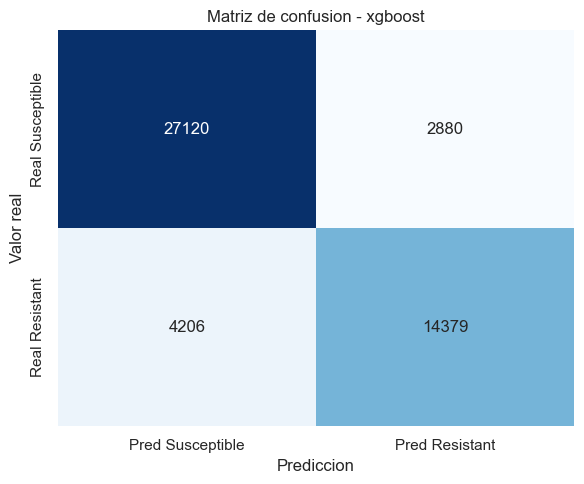

In [23]:
for nombre, datos_pred in predicciones.items():
    matriz = confusion_matrix(y_test, datos_pred["y_pred_test"], labels=[0, 1])
    df_matriz = pd.DataFrame(
        matriz,
        index=["Real Susceptible", "Real Resistant"],
        columns=["Pred Susceptible", "Pred Resistant"],
    )
    df_matriz.to_csv(RUTA_RESULTADOS / f"matriz_confusion_{nombre}.csv")

    plt.figure(figsize=(6, 5))
    sns.heatmap(df_matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Matriz de confusion - {nombre}")
    plt.xlabel("Prediccion")
    plt.ylabel("Valor real")
    plt.tight_layout()
    plt.savefig(RUTA_GRAFICAS / f"01_matriz_confusion_{nombre}.png", dpi=180)
    plt.show()

## 10. Comparacion visual de scores

Estas graficas sirven para el frontend, poster o exposicion porque comparan los modelos sin entrar en demasiado codigo.

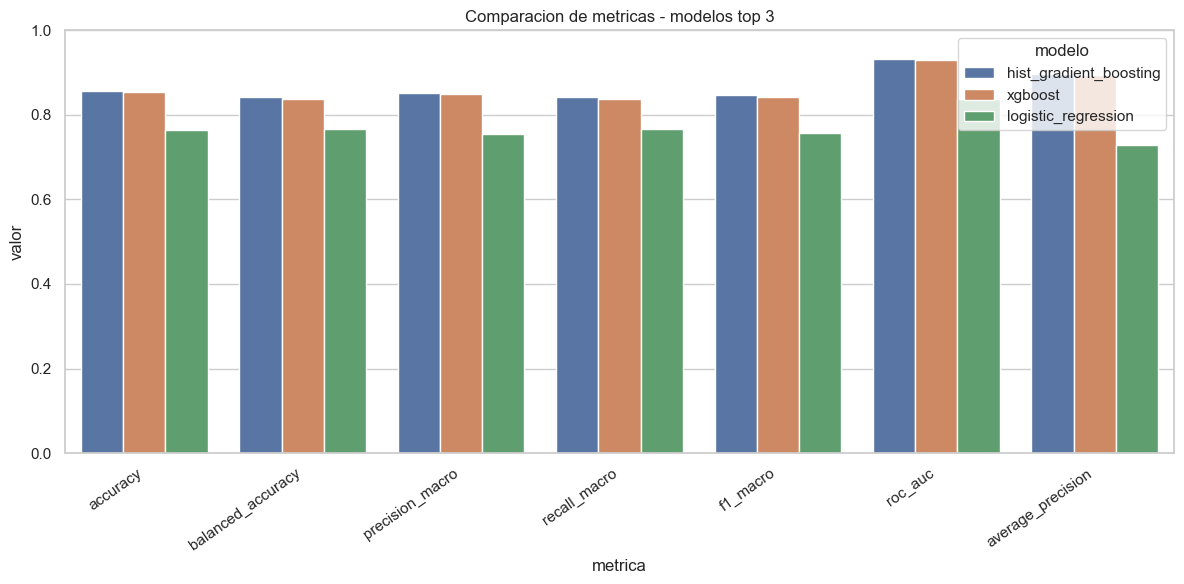

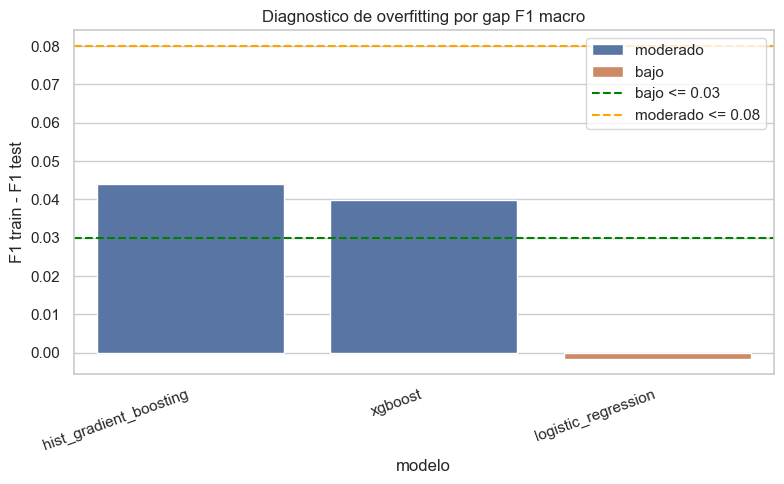

In [24]:
metricas_largas = df_metricas.melt(
    id_vars="modelo",
    value_vars=["accuracy", "balanced_accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc", "average_precision"],
    var_name="metrica",
    value_name="valor",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=metricas_largas, x="metrica", y="valor", hue="modelo")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.title("Comparacion de metricas - modelos top 3")
plt.tight_layout()
plt.savefig(RUTA_GRAFICAS / "02_comparacion_metricas_top3.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=df_metricas, x="modelo", y="gap_overfitting_f1_macro", hue="nivel_overfitting", dodge=False)
plt.axhline(UMBRAL_OVERFITTING_BAJO, color="green", linestyle="--", label="bajo <= 0.03")
plt.axhline(UMBRAL_OVERFITTING_MODERADO, color="orange", linestyle="--", label="moderado <= 0.08")
plt.title("Diagnostico de overfitting por gap F1 macro")
plt.ylabel("F1 train - F1 test")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_GRAFICAS / "03_overfitting_gap_top3.png", dpi=180)
plt.show()

## 11. Mejor modelo final segun F1 macro

El mejor modelo se selecciona por `f1_macro` en test. Si hay empate practico, se revisan `balanced_accuracy`, overfitting y matriz de confusion.

In [25]:
mejor_nombre = df_metricas.iloc[0]["modelo"]
mejor_modelo = mejores_modelos[mejor_nombre]

print("Mejor modelo segun F1 macro:", mejor_nombre)
display(df_metricas.head(3))

df_metricas.head(1).to_csv(RUTA_RESULTADOS / "04_mejor_modelo_top3.csv", index=False)

Mejor modelo segun F1 macro: hist_gradient_boosting


,modelo,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,mse,f1_macro_train,f1_macro_test,gap_overfitting_f1_macro,nivel_overfitting,roc_auc,average_precision
0,hist_gradient_boosting,0.857219,0.843119,0.852026,0.843119,0.847029,0.142781,0.891030,0.847029,0.044001,moderado,0.932128,0.897263
2,xgboost,0.854153,0.838844,0.849433,0.838844,0.843382,0.145847,0.883252,0.843382,0.039871,moderado,0.929739,0.894868
1,logistic_regression,0.763775,0.767411,0.754936,0.767411,0.757178,0.236225,0.755581,0.757178,-0.001597,bajo,0.838217,0.729493


## 12. Importancia de variables

Se calcula importancia por permutacion sobre una muestra del conjunto test. Esto permite comparar modelos de forma uniforme, incluso si internamente calculan las variables de manera diferente.

Interpretacion: si al mezclar una variable baja mucho el F1 macro, esa variable era importante para el modelo.

Calculando importancia: hist_gradient_boosting


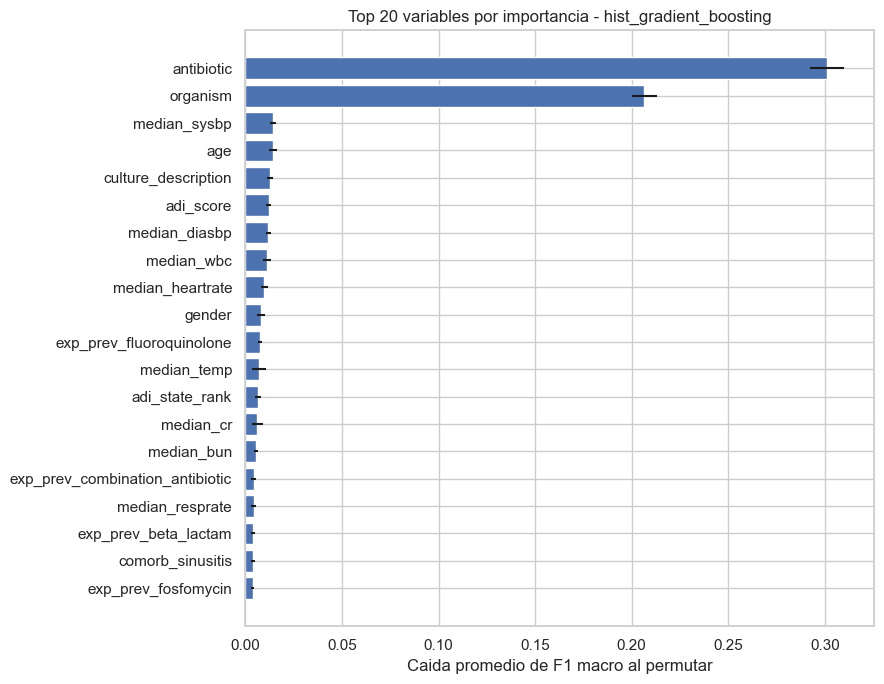

Calculando importancia: logistic_regression


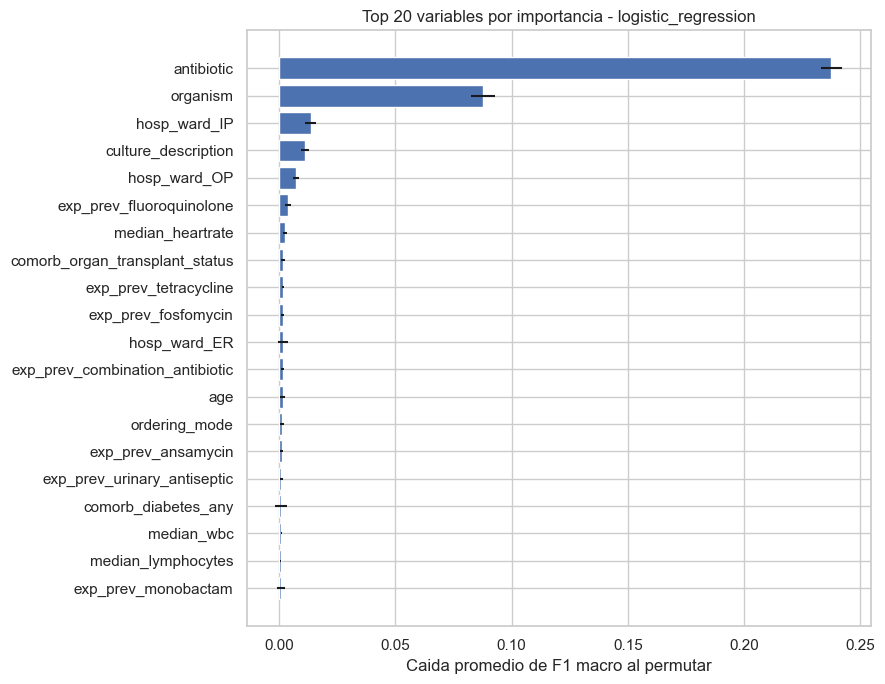

Calculando importancia: xgboost


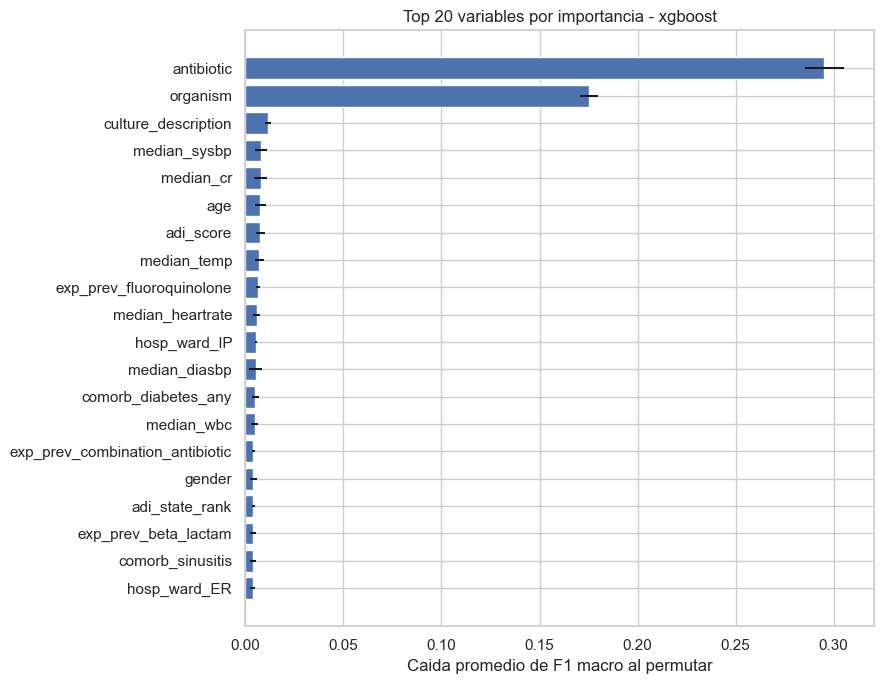

In [26]:
if CALCULAR_IMPORTANCIA:
    rng = np.random.default_rng(RANDOM_STATE)
    n_imp = min(N_FILAS_IMPORTANCIA, len(X_test))
    indices = rng.choice(len(X_test), size=n_imp, replace=False)
    X_imp = X_test.iloc[indices].copy()
    y_imp = y_test.iloc[indices].copy() if hasattr(y_test, "iloc") else pd.Series(y_test).iloc[indices]

    for nombre, modelo in mejores_modelos.items():
        print("Calculando importancia:", nombre)
        imp = permutation_importance(
            modelo,
            X_imp,
            y_imp,
            scoring="f1_macro",
            n_repeats=N_REPEATS_IMPORTANCIA,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        )
        df_imp = pd.DataFrame({
            "variable": X_imp.columns,
            "importancia_media": imp.importances_mean,
            "importancia_std": imp.importances_std,
        }).sort_values("importancia_media", ascending=False)

        df_imp.to_csv(RUTA_RESULTADOS / f"05_importancia_permutacion_{nombre}.csv", index=False)

        top = df_imp.head(20).sort_values("importancia_media", ascending=True)
        plt.figure(figsize=(9, 7))
        plt.barh(top["variable"], top["importancia_media"], xerr=top["importancia_std"])
        plt.title(f"Top 20 variables por importancia - {nombre}")
        plt.xlabel("Caida promedio de F1 macro al permutar")
        plt.tight_layout()
        plt.savefig(RUTA_GRAFICAS / f"04_importancia_variables_{nombre}.png", dpi=180)
        plt.show()
else:
    print("Importancia desactivada. Cambia CALCULAR_IMPORTANCIA=True para calcularla.")

## 13. Prediccion en vivo con datos del test

Esta celda simula como se veria una prediccion individual. El modelo entrega probabilidad de `Susceptible` y probabilidad de `Resistant`.

Para probar otro caso, cambia `INDICE_EJEMPLO` o reemplaza los valores del diccionario `caso_manual`.

In [27]:
INDICE_EJEMPLO = 0

caso = X_test.iloc[[INDICE_EJEMPLO]].copy()
real = MAPEO_INVERSO[int(y_test.iloc[INDICE_EJEMPLO] if hasattr(y_test, "iloc") else y_test[INDICE_EJEMPLO])]

print("Valor real:", real)
display(caso.T.rename(columns={caso.index[0]: "valor"}).head(80))

filas_pred = []
for nombre, modelo in mejores_modelos.items():
    pred = int(modelo.predict(caso)[0])
    prob_resistant = obtener_prob_resistant(modelo, caso)
    if prob_resistant is not None:
        p_res = float(prob_resistant[0])
        p_sus = 1 - p_res
    else:
        p_res = np.nan
        p_sus = np.nan

    filas_pred.append({
        "modelo": nombre,
        "prediccion": MAPEO_INVERSO[pred],
        "prob_susceptible": p_sus,
        "prob_resistant": p_res,
    })

df_pred_vivo = pd.DataFrame(filas_pred)
display(df_pred_vivo)
df_pred_vivo.to_csv(RUTA_RESULTADOS / "06_prediccion_en_vivo_ejemplo.csv", index=False)

Valor real: Resistant


,valor
ordering_mode,Outpatient
culture_description,URINE
organism,KLEBSIELLA PNEUMONIAE
antibiotic,Ampicillin
age,55-64 years
gender,0
hosp_ward_IP,0
hosp_ward_OP,1
hosp_ward_ER,0
hosp_ward_ICU,0


,modelo,prediccion,prob_susceptible,prob_resistant
0,hist_gradient_boosting,Resistant,0.002371,0.997629
1,logistic_regression,Resistant,0.201354,0.798646
2,xgboost,Resistant,0.001773,0.998227


## 14. Plantilla para prediccion manual

Esta plantilla toma un caso real del test como base. Para una demo, puedes editar valores clave como `organism`, `antibiotic`, edad, sala hospitalaria, exposicion previa o comorbilidades.

Importante: el diccionario debe conservar las mismas columnas de entrenamiento.

In [28]:
caso_manual = X_test.iloc[0].to_dict()

# Ejemplos de edicion. Solo se aplican si la columna existe en el dataset.
cambios_demo = {
    "organism": "Escherichia coli",
    "antibiotic": "CIPROFLOXACIN",
    "gender": "Female",
}

for col, valor in cambios_demo.items():
    if col in caso_manual:
        caso_manual[col] = valor

df_caso_manual = pd.DataFrame([caso_manual], columns=X_train.columns)

filas_manual = []
for nombre, modelo in mejores_modelos.items():
    pred = int(modelo.predict(df_caso_manual)[0])
    prob_resistant = obtener_prob_resistant(modelo, df_caso_manual)
    if prob_resistant is not None:
        p_res = float(prob_resistant[0])
        p_sus = 1 - p_res
    else:
        p_res = np.nan
        p_sus = np.nan

    filas_manual.append({
        "modelo": nombre,
        "prediccion": MAPEO_INVERSO[pred],
        "prob_susceptible": p_sus,
        "prob_resistant": p_res,
    })

display(df_caso_manual.T.rename(columns={0: "valor_demo"}).head(80))
display(pd.DataFrame(filas_manual))

,valor_demo
ordering_mode,Outpatient
culture_description,URINE
organism,Escherichia coli
antibiotic,CIPROFLOXACIN
age,55-64 years
gender,Female
hosp_ward_IP,0
hosp_ward_OP,1
hosp_ward_ER,0
hosp_ward_ICU,0


,modelo,prediccion,prob_susceptible,prob_resistant
0,hist_gradient_boosting,Susceptible,0.994138,0.005862
1,logistic_regression,Susceptible,0.760791,0.239209
2,xgboost,Susceptible,0.858308,0.141692


## 15. Simulador editable de prediccion

Este bloque permite simular una prediccion ingresando manualmente valores de variables. Para no llenar todas las columnas del dataset una por una, se toma un caso real como base y solo reemplazas las variables que quieras probar.

Edita el diccionario `valores_usuario`. Si escribes una variable que no existe, el notebook la reporta y la ignora. La salida muestra la prediccion y las probabilidades estimadas por cada modelo.

In [29]:
# Cambia este indice si quieres partir de otro paciente/cultivo real del conjunto de prueba.
INDICE_BASE_SIMULACION = 0

# Edita aqui los valores que quieras simular.
# No tienes que escribir todas las columnas: solo las que quieras cambiar.
valores_usuario = {
    "organism": "Escherichia coli",
    "antibiotic": "CIPROFLOXACIN",
    "gender": "Female",
    # "age": 65,
    # "hosp_ward_ICU": 0,
    # "hosp_ward_ER": 1,
    # "hosp_ward_IP": 0,
    # "hosp_ward_OP": 0,
    # "exp_prev_fluoroquinolone": 1,
    # "exp_prev_beta_lactam": 1,
    # "comorb_diabetes_any": 1,
    # "comorb_renal_failure": 0,
}

caso_simulado = X_test.iloc[[INDICE_BASE_SIMULACION]].copy()
columnas_no_encontradas = []

for columna, valor in valores_usuario.items():
    if columna in caso_simulado.columns:
        caso_simulado.loc[:, columna] = valor
    else:
        columnas_no_encontradas.append(columna)

if columnas_no_encontradas:
    print("Variables ignoradas porque no existen en el dataset:", columnas_no_encontradas)

print("Valores modificados en la simulacion:")
display(pd.DataFrame([
    {"variable": col, "valor_ingresado": val, "existe_en_dataset": col in X_train.columns}
    for col, val in valores_usuario.items()
]))

filas_simulacion = []
for nombre, modelo in mejores_modelos.items():
    pred = int(modelo.predict(caso_simulado)[0])
    prob_resistant = obtener_prob_resistant(modelo, caso_simulado)
    if prob_resistant is not None:
        p_res = float(prob_resistant[0])
        p_sus = 1 - p_res
    else:
        p_res = np.nan
        p_sus = np.nan

    filas_simulacion.append({
        "modelo": nombre,
        "prediccion": MAPEO_INVERSO[pred],
        "prob_susceptible": p_sus,
        "prob_resistant": p_res,
    })

df_simulacion = pd.DataFrame(filas_simulacion).sort_values("prob_resistant", ascending=False)
display(df_simulacion)

print("Caso completo usado por el modelo. Se muestran las primeras 100 variables para revision:")
display(caso_simulado.T.rename(columns={caso_simulado.index[0]: "valor_simulado"}).head(100))

df_simulacion.to_csv(RUTA_RESULTADOS / "07_prediccion_simulada_usuario.csv", index=False)
caso_simulado.to_csv(RUTA_RESULTADOS / "08_caso_simulado_usuario.csv", index=False)

Valores modificados en la simulacion:


,variable,valor_ingresado,existe_en_dataset
0,organism,Escherichia coli,True
1,antibiotic,CIPROFLOXACIN,True
2,gender,Female,True


,modelo,prediccion,prob_susceptible,prob_resistant
1,logistic_regression,Susceptible,0.760791,0.239209
2,xgboost,Susceptible,0.858308,0.141692
0,hist_gradient_boosting,Susceptible,0.994138,0.005862


Caso completo usado por el modelo. Se muestran las primeras 100 variables para revision:


,valor_simulado
ordering_mode,Outpatient
culture_description,URINE
organism,Escherichia coli
antibiotic,CIPROFLOXACIN
age,55-64 years
gender,Female
hosp_ward_IP,0
hosp_ward_OP,1
hosp_ward_ER,0
hosp_ward_ICU,0


## 16. Archivos generados

Al ejecutar completo este notebook quedan listos:

- `00_variables_usadas_top3.csv`
- `01_modelos_ajustados_configuracion_fija.csv`
- `02_configuraciones_destacadas_top3.csv`
- `03_metricas_test_top3.csv`
- `04_mejor_modelo_top3.csv`
- matrices de confusion por modelo
- reportes de clasificacion por modelo
- importancia de variables por permutacion
- imagenes comparativas en `GRAFICAS/top3_presentacion`
- `07_prediccion_simulada_usuario.csv`
- `08_caso_simulado_usuario.csv`